In [2]:
import math

In [3]:
def find_min_max(numbers):
    return (min(numbers), max(numbers))

print(find_min_max([5, 8, 2, 10, 3]))
print(find_min_max([7, 7, 7, 7]))

(2, 10)
(7, 7)


In [4]:
def min_max_normalize(value, data):
    return (value - min(data)) / (max(data) - min(data))

print(min_max_normalize(20, [10, 20, 30]))
print(min_max_normalize(10, [10, 20, 30]))

0.5
0.0


In [5]:
def compute_mean(numbers):
    if numbers == []:
        return 0
    return sum(numbers) / len(numbers)

print(compute_mean([2, 4, 6, 8]))
print(compute_mean([10, 20, 30]))
print(compute_mean([]))

5.0
20.0
0


In [6]:
def compute_sd(numbers):
    mean = sum(numbers) / len(numbers)
    variance = sum((x - mean) ** 2 for x in numbers) / len(numbers)
    return math.sqrt(variance)

print(compute_sd([2, 4, 4, 4, 5, 5, 7, 9]))
print(compute_sd([10, 10, 10, 10]))

2.0
0.0


In [7]:
def find_outliers(nums, threshold):
    sd = compute_sd(nums)
    m = compute_mean(nums)

    ans = []

    for x in nums:
        z = (x - m) / sd
        if abs(z) > threshold:
            ans.append(x)

    return ans

print(find_outliers([10, 12, 12, 13, 12, 11, 90], 2))
print(find_outliers([5, 6, 7, 8, 9, 10, 100], 3))

[90]
[]


In [8]:
def median(arr):
    n = len(arr)
    mid = n // 2

    if n % 2 == 0:
        return (arr[mid-1] + arr[mid]) / 2
    else:
        return arr[mid]


def compute_iqr(nums):
    nums = sorted(nums)
    n = len(nums)

    q2 = median(nums)

    if n % 2 == 0:
        left = nums[:n//2]
        right = nums[n//2:]
    else:
        left = nums[:n//2]
        right = nums[n//2+1:]

    q1 = median(left)
    q3 = median(right)

    return q3 - q1


print(compute_iqr([1, 2, 3, 4, 5, 6, 7, 8, 9]))
print(compute_iqr([10, 20, 30, 40, 50, 60]))

5.0
30


In [9]:
def standardize(data):
    mean = compute_mean(data)
    sd = compute_sd(data)

    return [(x - mean) / sd if sd != 0 else 0 for x in data]

print(standardize([1, 2, 3, 4, 5]))
print(standardize([10, 10, 10]))

[-1.414213562373095, -0.7071067811865475, 0.0, 0.7071067811865475, 1.414213562373095]
[0, 0, 0]


In [10]:
def compute_rmse(actual, predicted):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(actual, predicted)) / len(actual))

print(compute_rmse([2, 3, 4], [3, 2, 5]))
print(compute_rmse([1, 2, 3], [1, 2, 3]))
print(compute_rmse([2, 3, 4], [3, 1, 7]))

1.0
0.0
2.160246899469287


In [11]:
def compute_mae(actual, predicted):

    if len(actual) != len(predicted):
        raise ValueError("Lengths must match")

    total_error = 0
    count = 0

    for a, p in zip(actual, predicted):

        if isinstance(a, (int, float)):
            total_error += abs(a - p)
            count += 1

        else:
            for x, y in zip(a, p):
                total_error += abs(x - y)
                count += 1

    return total_error / count


actual = [3, 5, 2]
predicted = [2, 5, 4]
print(compute_mae(actual, predicted))

actual = [[1, 2], [3, 4], [5, 6]]
predicted = [[2, 2], [2, 5], [5, 7]]
print(compute_mae(actual, predicted)) 

1.0
0.6666666666666666


In [12]:
def compute_huber_loss(y, f, delta=1.0):

    huber_list = [
        0.5*(abs(a-b)**2) if abs(a-b) <= delta
        else delta*abs(a-b) - 0.5*delta**2
        for a, b in zip(y, f)
    ]

    return sum(huber_list) / len(huber_list)

print(compute_huber_loss([5, 2, 7], [4.8, 2.5, 10], 1))
print(compute_huber_loss([1, 2, 3], [1, 2, 3], 1))

0.8816666666666667
0.0


In [13]:
def closer_point(p, a , b):
    d1 = math.sqrt(sum((x - y)**2 for x, y in zip(p, a)))
    d2 = math.sqrt(sum((x - y)**2 for x, y in zip(p, b)))

    if d1 < d2:
        return "A"
    if d1 > d2:
        return "B"
    
    return "Equal"

print(closer_point([1, 2], [0, 0], [5, 5]))
print(closer_point([3, 3, 3], [0, 0, 0], [6, 6, 6]))
print(closer_point([10, 10], [2, 2], [20, 20]))

A
Equal
A


In [14]:
def find_nearest_neighbour(numbers, target):
    return min(numbers, key=lambda x: abs(x - target))

print(find_nearest_neighbour([2, 5, 8, 12], 6))
print(find_nearest_neighbour([1, 4, 10, 20], 15))

5
10


In [15]:
def find_nearest_neighbour(points, target):
    return min(points, key=lambda p: math.sqrt(sum((x - y)**2 for x, y in zip(p, target))))

print(find_nearest_neighbour([(1, 2), (3, 4), (6, 1)], (2, 3)))
print(find_nearest_neighbour([(0, 0), (5, 5), (2, 1)], (3, 3)))
points = [
    [1, 1, 1],
    [2, 2, 2],
    [-1, -1, -1]
]
target = [0, 0, 0]
print(find_nearest_neighbour(points, target))

(1, 2)
(2, 1)
[1, 1, 1]


In [16]:
def euclidean_distance(p1, p2):
    return sum((a - b) ** 2 for a, b in zip(p1, p2)) ** 0.5

def manhattan_distance(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2))

def find_nearest_neighbour(target, points, distance_func):
    return min(points, key=lambda p: distance_func(p, target))

print(find_nearest_neighbour([1, 2], [[3, 4], [2, 2], [0, 0]], euclidean_distance))

print(find_nearest_neighbour([1, 2, 3], [[5, 5, 5], [0, 0, 0], [2, 2, 2]], manhattan_distance))


[2, 2]
[2, 2, 2]


In [17]:
def multiply_polynomial(poly, num):
    return [p * num for p in poly]

print(multiply_polynomial([2, 0, 3, 10], 5))
print(multiply_polynomial([1, -2, 4], 3))

[10, 0, 15, 50]
[3, -6, 12]


In [18]:
def add_polynomials(p1, p2):

    i = len(p1) - 1
    j = len(p2) - 1
    res = []

    while i >= 0 or j >= 0:

        a = p1[i] if i >= 0 else 0
        b = p2[j] if j >= 0 else 0

        res.append(a + b)

        i -= 1
        j -= 1

    return res[::-1]


print(add_polynomials([2, 0, 3, 10], [1, 4, 0, 6]))
print(add_polynomials([5, 2], [3]))

[3, 4, 3, 16]
[5, 5]


In [19]:
def multiply_polynomials(p1, p2):

    n = len(p1)
    m = len(p2)

    res = [0] * (n + m - 1)

    for i in range(n):
        for j in range(m):
            res[i + j] += p1[i] * p2[j]

    return res

print(multiply_polynomials([2, 3], [1, 4]))
print(multiply_polynomials([2, 0, 3, 10], [1, 2]))

[2, 11, 12]
[2, 4, 3, 16, 20]


In [20]:
def solve_for_first_variable(equation, vars, st):
    eq = equation[-1]
    l = len(equation) - 2
    for i in range(len(vars) -1, -1, -1):
        eq = eq - vars[i] * equation[l]
        l -= 1
    return eq / equation[st]

print(solve_for_first_variable([3, 4, 6, 20], [5, 6], 0))
print(solve_for_first_variable([2, 5, 7], [4], 0))

-12.0
-6.5


In [21]:
def lcm(a, b):
    mn = min(a, b)
    i = 2
    ans = 1
    while i <= mn:
        if a == 1 and b == 1:
            break
        if a % i == 0 and b % i == 0:
            a = a // i
            b = b // i
            ans = ans * i
        else:
            i = i + 1
    ans = ans * a * b        
    return ans

def eliminate_variable(eq1, eq2, var_index):

    c1 = eq1[var_index]
    c2 = eq2[var_index]

    coeff = lcm(abs(c1), abs(c2))

    cf1 = coeff / c1
    cf2 = coeff / c2

    eq1 = [cf1 * x for x in eq1]
    eq2 = [cf2 * x for x in eq2]
    
    eq1[var_index] = 0
    eq2[var_index] = 0
    return [a - b for a, b in zip(eq1, eq2)]

print(eliminate_variable([2, 3, 8], [4, -1, 2], 0))
print(eliminate_variable([1, 2, 3], [3, 1, 7], 1))

print(eliminate_variable([2, 3, 5], [1, -1, -10], 0))
print(eliminate_variable([1, 1, 4], [2, -1, 1], 1))


[0, 7.0, 14.0]
[-5.0, 0, -11.0]
[0, 5.0, 25.0]
[3.0, 0, 5.0]


In [22]:
def solve_equations(equations, st,en):
    
    print("Iteration ", st)
    print("Equations ", equations)

    if st >= en:
        return [equations[0][-1]/equations[0][-2]]
    
    eq1 = equations[0]
    print(eq1)

    nextEq = []
    for i in range(1, len(equations)):
        nextEq.append(eliminate_variable(equations[i], equations[i-1], st))
    print(nextEq)

    ans = solve_equations(nextEq, st + 1, en)

    print(equations[0], ans)
    cur = solve_for_first_variable(equations[0], ans, st)
    print("Cur ", cur)

    return [cur] + ans

print("Final Output : ", solve_equations([[2, 3, 8], [4, -1, 2]], 0, 1))
print()
print("Final Output : ", solve_equations([[2, 3, 4, 0], [5, 1, 1, 1], [1, 1, 2, 3]],0,2))
        

Iteration  0
Equations  [[2, 3, 8], [4, -1, 2]]
[2, 3, 8]
[[0, -7.0, -14.0]]
Iteration  1
Equations  [[0, -7.0, -14.0]]
[2, 3, 8] [2.0]
Cur  1.0
Final Output :  [1.0, 2.0]

Iteration  0
Equations  [[2, 3, 4, 0], [5, 1, 1, 1], [1, 1, 2, 3]]
[2, 3, 4, 0]
[[0, -13.0, -18.0, 2.0], [0, 4.0, 9.0, 14.0]]
Iteration  1
Equations  [[0, -13.0, -18.0, 2.0], [0, 4.0, 9.0, 14.0]]
[0, -13.0, -18.0, 2.0]
[[0.0, 0, 45.0, 190.0]]
Iteration  2
Equations  [[0.0, 0, 45.0, 190.0]]
[0, -13.0, -18.0, 2.0] [4.222222222222222]
Cur  -6.0
[2, 3, 4, 0] [-6.0, 4.222222222222222]
Cur  0.5555555555555554
Final Output :  [0.5555555555555554, -6.0, 4.222222222222222]


In [23]:
import random

def fair_coin_toss():
    r = random.random()   # gives a number in [0.0, 1.0)

    if r < 0.5:
        print("HEAD")
    else:
        print("TAIL")
    
fair_coin_toss()

HEAD


In [24]:
def biased_coin_toss(p):
    r = random.random()   # gives a number in [0.0, 1.0)

    if r < p:
        print("HEAD")
    else:
        print("TAIL")
    
biased_coin_toss(0.3)

TAIL


In [25]:
def weighted_choice(probabilities):
    r = random.random()
    cumulative = 0

    for i, p in enumerate(probabilities):
        cumulative += p
        if r < cumulative:
            return i

weighted_choice([0.1, 0.2, 0.3, 0.4])

3

In [26]:
def normalize_to_probabilities(numbers):
    total = sum(numbers)
    return [x / total for x in numbers]

print(normalize_to_probabilities([1, 2, 2]))
print(normalize_to_probabilities([3, 3, 4]))

[0.2, 0.4, 0.4]
[0.3, 0.3, 0.4]


In [27]:
import math

def softmax(values):
    m = max(values)             
    e = [math.exp(x - m) for x in values]
    s = sum(e)
    return [i / sum(e) for i in e]


print(softmax([1, 2, 3]))
print(softmax([1000, 1001, 1002]))

[0.09003057317038046, 0.24472847105479764, 0.6652409557748218]
[0.09003057317038046, 0.24472847105479764, 0.6652409557748218]


In [28]:
def softmax_with_temperature(values, T):
    m = max(values)             
    e = [math.exp(x/T - m/T) for x in values]
    s = sum(e)
    return [i / sum(e) for i in e]

print(softmax_with_temperature([1, 2, 3], 1))
print(softmax_with_temperature([1, 2, 3], 0.5))
print(softmax_with_temperature([1, 2, 3], 2))

[0.09003057317038046, 0.24472847105479764, 0.6652409557748218]
[0.015876239976466765, 0.11731042782619838, 0.8668133321973349]
[0.1863237232258476, 0.3071958857184984, 0.506480391055654]


In [34]:
def weighted_choice_with_temperature(weights, T):
    scaled = [w ** (1.0 / T) for w in weights]
    weighted_scaled = [w / sum(scaled) for w in scaled]
    r = random.random() 
    cumulative = 0
    for i in range(len(weighted_scaled)):
        cumulative += weighted_scaled[i]
        if r < cumulative:
            return weights[i]
    return -1

print(weighted_choice_with_temperature([1, 2, 8], T=0.5))
print(weighted_choice_with_temperature([1, 2, 8], T=1.0))
print(weighted_choice_with_temperature([1, 2, 8], T=2.0))

print(weighted_choice_with_temperature([3, 3, 3], T=0.3))
print(weighted_choice_with_temperature([3, 3, 3], T=2.0))

8
2
2
3
3


In [35]:
def flatter_list(l):
    return [item for sublist in l for item in sublist]

print(flatter_list([[1, 2, 3], [4, 5, 6], [7, 8, 9]]))

[1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
def flatten_with_delim(l):
    result = []

    for item in l:
        if isinstance(item, list):
            result.append('[')
            result.extend(flatten_with_delim(item))
            result.append(']')
        else:
            result.append(item)

    return result


def calculate(val1, val2, op):
    if op == '*':
        return val1 * val2
    if op == '/':
        return val2 / val1
    if op == '-':
        return val2 - val1
    if op == '+':
        return val2 + val1
    
    return 0

def solve_expression(exp):
    exp = flatten_with_delim(exp)
    print(exp)
    operators = []
    nums = []
    for i in range(len(exp)):
        if exp[i] == ']':
            op = operators.pop()
            val1 = nums.pop()
            val2 = nums.pop()
            nums.append(calculate(val1, val2, op))
        elif isinstance(exp[i], str) and exp[i] in "*/-+":
            operators.append(exp[i])
        elif exp[i] != '[':
            nums.append(exp[i])
            
    print(nums)
    print(operators)
    op = operators.pop()
    val1 = nums.pop()
    val2 = nums.pop()
    nums.append(calculate(val1, val2, op))

    return nums.pop()


print(solve_expression(["*", ["+", 20, 40], 90]))
print(solve_expression(["-", ["*", ["/", 100, 10], 5], 15]))

['*', '[', '+', 20, 40, ']', 90]
[60, 90]
['*']
5400
['-', '[', '*', '[', '/', 100, 10, ']', 5, ']', 15]
[50.0, 15]
['-']
35.0


In [ ]:
def close(ex, x, y, k):
    mn = None
    cl = None
    point = []
    for i, j in zip(x, y):
        # diff = sum(abs(i1-k1) for i1, k1 in zip(ex, i))
        diff = sum((i1-k1)**2 for i1, k1 in zip(ex, i))

        if mn is None or diff < mn:
            mn = diff
            cl = j
        point.append([diff, j])
    point.sort(key=lambda x: x[0])
    print(point)
    # return cl
    return [x[1] for x in point[:k]]

x = [[1], [2], [3]]
y = [100, 200, 300]

close([2.6], x, y, 2)


[[0.15999999999999992, 300], [0.3600000000000001, 200], [2.5600000000000005, 100]]


[300, 200]

In [55]:
class LineModel:
    def __init__(self):
        self.m = None
        self.c = None
    
    def fit(self, data):
        eq = []
        for d in data:
            eq.append([d[0], 1, d[1]])
        ans = solve_equations(eq, 0, 1)
        print(ans)
        self.m = ans[0]
        self.c = ans[1]
    
    def predict(self, x):
        return self.m * x + self.c

model = LineModel()
model.fit([[1,2],[3,4],[5,6]])
model.predict(5)

Iteration  0
Equations  [[1, 1, 2], [3, 1, 4], [5, 1, 6]]
[1, 1, 2]
[[0, -2.0, -2.0], [0, -2.0, -2.0]]
Iteration  1
Equations  [[0, -2.0, -2.0], [0, -2.0, -2.0]]
[1, 1, 2] [1.0]
Cur  1.0
[1.0, 1.0]


6.0

In [9]:
import math

class Vector:

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def add(self, other):
        return Vector(self.x + other.x, self.y + other.y)

    def multiply(self, scalar):
        return Vector(self.x * scalar, self.y * scalar)

    def dist(self, other):
        return math.sqrt((self.x - other.x)**2 + (self.y - other.y)**2)

    def magnitude(self):
        return math.sqrt(self.x**2 + self.y**2)

    def turn(self, theta_ccw):
        cos_theta = math.cos(theta_ccw)
        sin_theta = math.sin(theta_ccw)

        new_x = self.x * cos_theta - self.y * sin_theta
        new_y = self.x * sin_theta + self.y * cos_theta

        return Vector(new_x, new_y)

    def __repr__(self):
        return f"Vector({self.x}, {self.y})"
    
position = Vector(3, 4)
move = Vector(-2, 3)

new_position = position.add(move)
print(new_position.dist(position))  # sqrt(13)

wind1 = Vector(10, 0)
move_wind1 = wind1.multiply(2)
new_position = new_position.add(move_wind1)

wind2 = Vector(5, 3)
move_wind2 = wind2.multiply(2)
new_position = new_position.add(move_wind2)

print("Before turn:", new_position)

# Rotate 90 degrees (pi/2 radians)
rotated = new_position.turn(math.pi / 2)

print("After 90° turn:", rotated)
print("Magnitude preserved:", new_position.magnitude(), rotated.magnitude())

3.605551275463989
Before turn: Vector(31, 13)
After 90° turn: Vector(-12.999999999999998, 31.0)
Magnitude preserved: 33.61547262794322 33.61547262794322


In [63]:
def dot_product(v1, v2):
    return v1.x * v2.x + v1.y * v2.y


print(dot_product(Vector(1,0) , Vector(0, 1)))

0


In [1]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


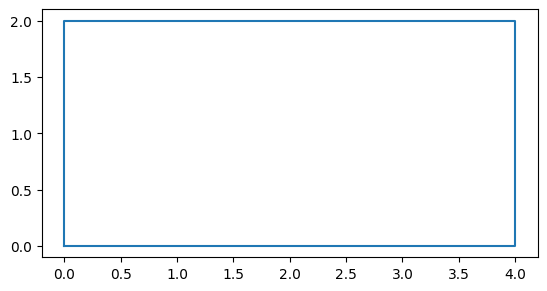

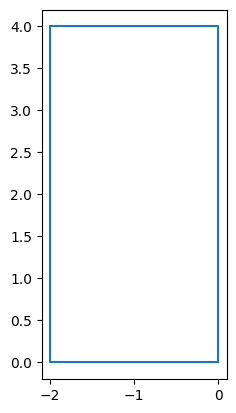

In [12]:
x = [0, 4, 4, 0, 0]
y = [0, 0, 2, 2, 0]

plt.plot(x, y)
plt.gca().set_aspect('equal')
plt.show()

new_x = []
new_y = []

for a, b in zip(x, y):
    p = Vector(a, b)
    new_p = p.turn(math.pi / 2)
    new_x.append(new_p.x)
    new_y.append(new_p.y)

plt.plot(new_x, new_y)
plt.gca().set_aspect('equal')
plt.show()

In [23]:
class Node:
    left = None
    right = None

    def __init__(self, value):
        self.value = value

    def print(self):
        if self is None:
            return
        if self.left is not None:
            self.left.print()
        print(self.value)
        if self.right is not None:
            self.right.print()
    
    def search(self, value):
        if self is None:
            return False
        if self.value == value:
            return True
        if value < self.value:
            if self.left:
                return self.left.search(value)
            return False
        else:
            if self.right:
                return self.right.search(value)
            return False
    
    def insert(self, value):
        if value < self.value:
            if self.left is None:
                self.left = Node(value)
            else:
                self.left.insert(value)
        else:
            if self.right is None:
                self.right = Node(value)
            else:
                self.right.insert(value)


root = Node(5)

root.insert(1)
root.insert(8)
root.insert(3)
root.insert(6)

root.print()
print(root.search(3))
print(root.search(10))

1
3
5
6
8
True
False


In [28]:
class DecisionTree:

    def __init__(self, feature, threshold, yes, no):
        self.feature = feature
        self.threshold = threshold
        self.yes = yes
        self.no = no

    def check(self, data):
        value = data.get(self.feature)

        if value is None:
            return "Missing Feature"

        if value >= self.threshold:
            if isinstance(self.yes, DecisionTree):
                return self.yes.check(data)
            return self.yes
        else:
            if isinstance(self.no, DecisionTree):
                return self.no.check(data)
            return self.no

dt = DecisionTree(
    'salary', 1000,
    DecisionTree(
        'experience', 5,
        "Offer",
        DecisionTree('Developer', True, "Offer", "Reject")
    ),
    DecisionTree('QA', True, "Offer", "Reject")
)

print(dt.check({
    'salary': 3000,
    'experience': 5,
}))  

print(dt.check({
    'salary': 3000,
    'experience': 4,
    'Developer': True,
}))  

print(dt.check({
    'salary': 3000,
    'experience': 4,
    'Developer': False,
}))  

print(dt.check({
    'salary': 800,
    'QA': True,
}))  

print(dt.check({
    'salary': 800,
    'QA': False,
}))  


Offer
Offer
Reject
Offer
Reject


In [1]:

def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])

    return merge(left_half, right_half)

def merge(left, right):
    merged = []
    i = j = 0

    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])

    return merged

print(merge_sort([38, 27, 43, 3, 9, 82, 10]))




[3, 9, 10, 27, 38, 43, 82]
